In [1]:
from ucimlrepo import fetch_ucirepo 
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import zero_one_loss, f1_score

import sklearn.tree as tree

  
# fetch dataset 
adult = fetch_ucirepo(id=2) 
  
# data (as pandas dataframes) 
Xo = adult.data.features.to_numpy()
yo = adult.data.targets.to_numpy()
yo = np.where(yo.ravel() == '<=50K', -1, 1)

In [2]:
print("Features shape:", Xo.shape)
print("Targets shape:", yo.shape)

print("First 5 feature rows:\n", Xo[:5])
print("First 5 target values:\n", yo[:5])

Features shape: (48842, 14)
Targets shape: (48842,)
First 5 feature rows:
 [[39 'State-gov' 77516 'Bachelors' 13 'Never-married' 'Adm-clerical'
  'Not-in-family' 'White' 'Male' 2174 0 40 'United-States']
 [50 'Self-emp-not-inc' 83311 'Bachelors' 13 'Married-civ-spouse'
  'Exec-managerial' 'Husband' 'White' 'Male' 0 0 13 'United-States']
 [38 'Private' 215646 'HS-grad' 9 'Divorced' 'Handlers-cleaners'
  'Not-in-family' 'White' 'Male' 0 0 40 'United-States']
 [53 'Private' 234721 '11th' 7 'Married-civ-spouse' 'Handlers-cleaners'
  'Husband' 'Black' 'Male' 0 0 40 'United-States']
 [28 'Private' 338409 'Bachelors' 13 'Married-civ-spouse'
  'Prof-specialty' 'Wife' 'Black' 'Female' 0 0 40 'Cuba']]
First 5 target values:
 [-1 -1 -1 -1 -1]


In [3]:
print(np.unique(yo))

[-1  1]


In [4]:
# remove missing values
missing_mask = (Xo == "?")
rows_with_missing = np.sum(missing_mask, axis = 1) > 0
rows_to_keep = ~rows_with_missing
X = Xo[rows_to_keep]
y = yo[rows_to_keep]

print(X.shape)

(46443, 14)


In [5]:
features_with_missing = {
    'workclass' : 1,
    'occupation' : 6,
    'native-country': 13
}

In [6]:
features = ["Age",                  # int
            "Workclass",            # categorical
            "Fnlwgt",               # int
            "Education",            # categorical
            "Education Num",        # int
            "Marital Status",       # categorical
            "Occupation",           # categorical
            "Relationship",         # categorical
            "Race",                 # categorical  
            "Sex",                  # categorical   
            "Capital Gain",         # binary categorical
            "Capital Loss",         # int
            "Hours Per Week",       # int
            "Native Country",       # categorical
            "Income"]               # -1/1

## Statistics on rows with filled features

In [7]:
# statistics for int features
int_indices = [0, 2, 4, 10, 11, 12]
for i in int_indices:
    print(f"[{features[i]}]")
    feat_data = X[:, i]

    print(f"Mean: {np.mean(feat_data)}")
    print(f"Std: {np.std(feat_data)}")
    print(f"Min: {np.min(feat_data)}")
    print(f"Max: {np.max(feat_data)}\n")

[Age]
Mean: 38.553431087569706
Std: 13.390118320056452
Min: 17
Max: 90

[Fnlwgt]
Mean: 189668.27915939968
Std: 105672.55031383577
Min: 13492
Max: 1490400

[Education Num]
Mean: 10.10434295803458
Std: 2.556210249498046
Min: 1
Max: 16

[Capital Gain]
Mean: 1088.4662489503262
Std: 7468.922299328548
Min: 0
Max: 99999

[Capital Loss]
Mean: 88.20659733436686
Std: 403.8718997871633
Min: 0
Max: 4356

[Hours Per Week]
Mean: 40.74228624335207
Std: 12.159825020567746
Min: 1
Max: 99



In [8]:
# top 5 counts for categorical features
cat_indices = [1, 3, 5, 6, 7, 8, 9, 12, 13]
for i in cat_indices:
    print(f"[{features[i]}]")

    feat_data = X[:, i].astype(str)

    unique, counts = np.unique(feat_data, return_counts = True)

    indices = np.argsort(counts)[::-1]
    unique = unique[indices]
    counts = counts[indices]

    for i in range(min(5, len(unique))):
        print(f"{i + 1}. {unique[i]}: {counts[i]}")

    print()

[Workclass]
1. Private: 33496
2. Self-emp-not-inc: 3820
3. Local-gov: 3110
4. State-gov: 1962
5. Self-emp-inc: 1653

[Education]
1. HS-grad: 15123
2. Some-college: 10265
3. Bachelors: 7714
4. Masters: 2561
5. Assoc-voc: 1986

[Marital Status]
1. Married-civ-spouse: 21468
2. Never-married: 15160
3. Divorced: 6404
4. Separated: 1444
5. Widowed: 1352

[Occupation]
1. Prof-specialty: 6070
2. Craft-repair: 6043
3. Exec-managerial: 6012
4. Adm-clerical: 5562
5. Sales: 5438

[Relationship]
1. Husband: 18986
2. Not-in-family: 12004
3. Own-child: 6979
4. Unmarried: 4891
5. Wife: 2169

[Race]
1. White: 39879
2. Black: 4378
3. Asian-Pac-Islander: 1375
4. Amer-Indian-Eskimo: 445
5. Other: 366

[Sex]
1. Male: 31240
2. Female: 15203

[Hours Per Week]
1. 40: 21837
2. 50: 4145
3. 45: 2646
4. 60: 2107
5. 35: 1824

[Native Country]
1. United-States: 42166
2. Mexico: 918
3. Philippines: 285
4. nan: 274
5. Germany: 197



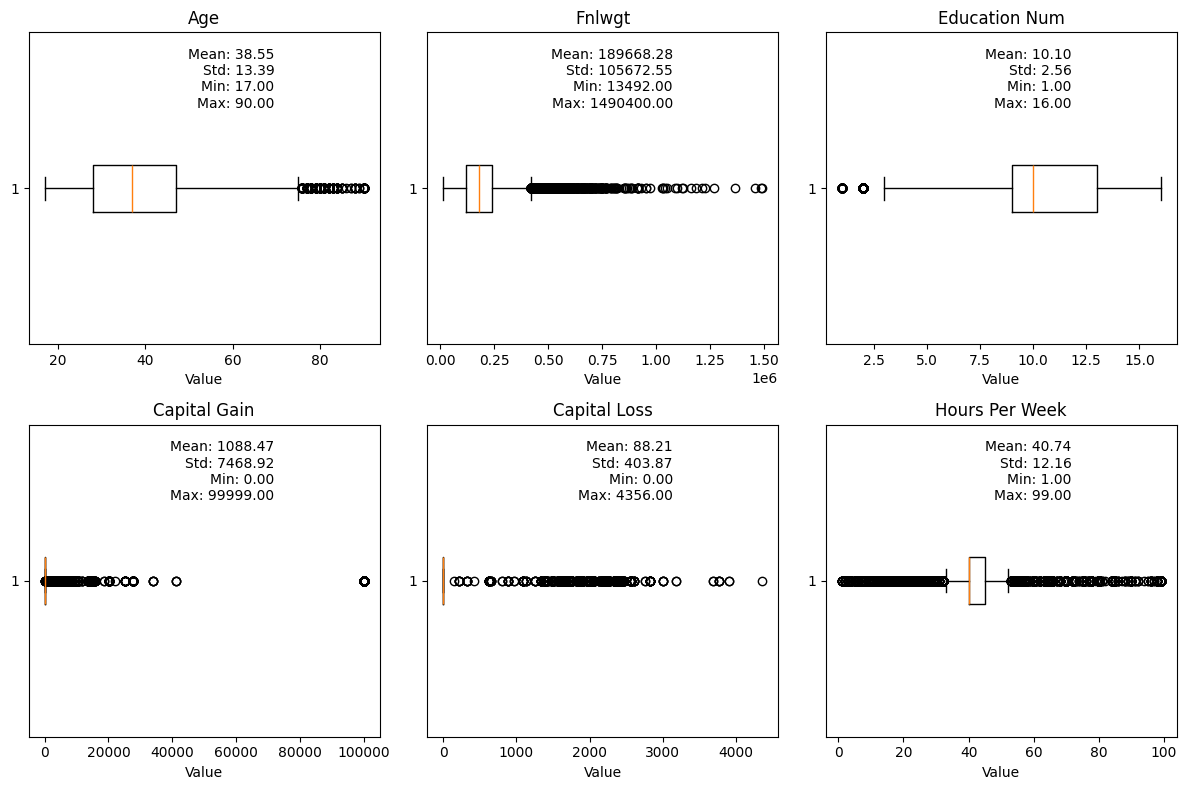

In [9]:
fig, axes = plt.subplots(2, 3, figsize=(12, 8))
fig.subplots_adjust(hspace = 0.5)
axes = axes.flatten()

plot_idx = 0
# plot the numerical data
for i in range(len(int_indices)):
    feat_idx = int_indices[i]

    feat_data = X[:, feat_idx].astype(float)

    axes[plot_idx].set_title(features[feat_idx], fontsize = 12)
    axes[plot_idx].boxplot(feat_data, vert = False)
    axes[plot_idx].set_xlabel("Value", fontsize = 10)

    stats_text = (f"Mean: {np.mean(feat_data):.2f}\nStd: {np.std(feat_data):.2f}\nMin: {np.min(feat_data):.2f}\nMax: {np.max(feat_data):.2f}")
    axes[plot_idx].text(0.7, 0.95, stats_text, verticalalignment="top", horizontalalignment="right", transform = axes[plot_idx].transAxes)

    plot_idx += 1

plt.tight_layout()


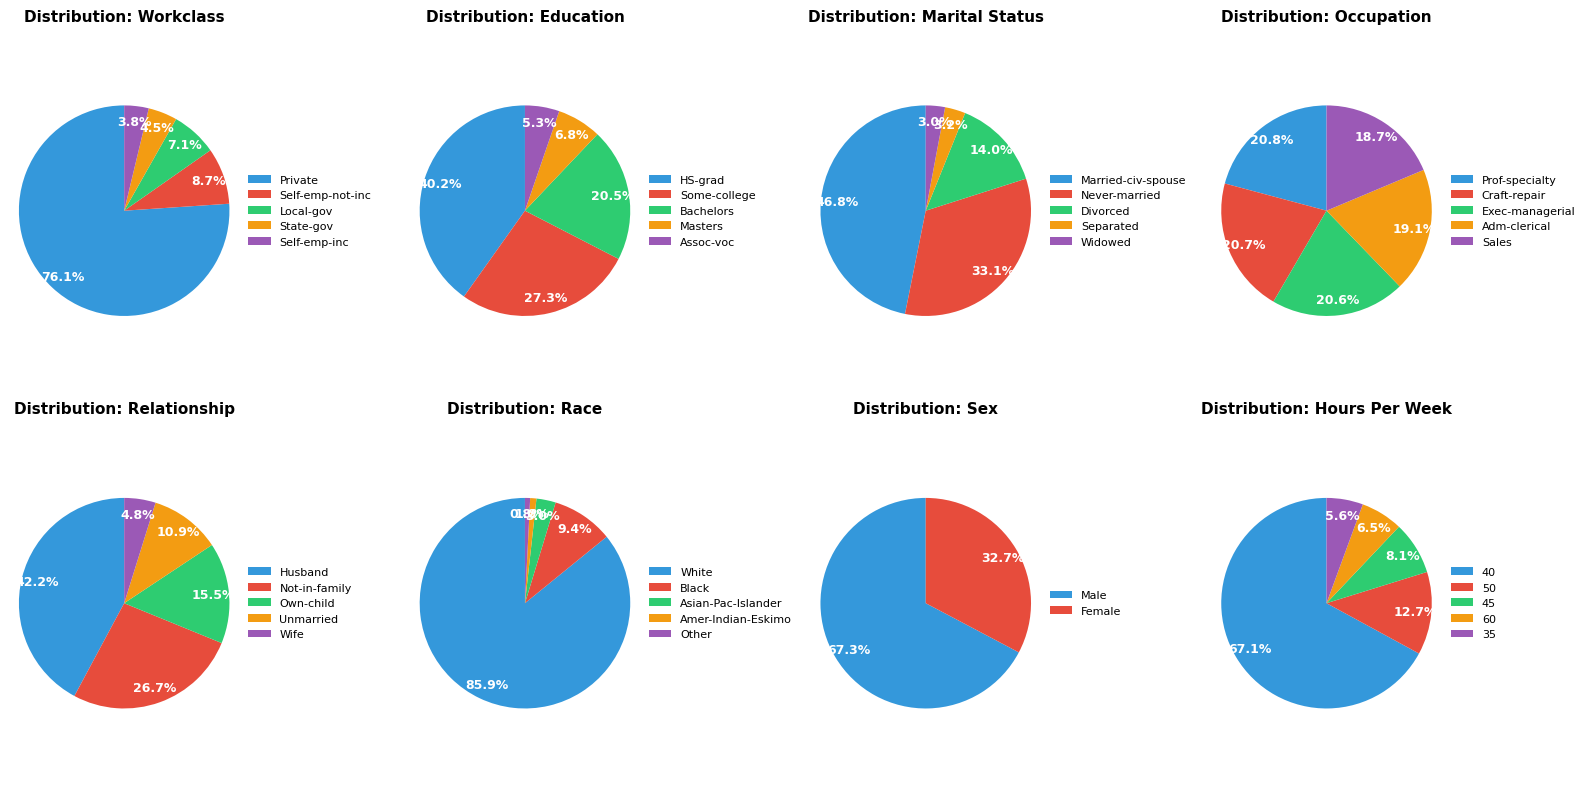

In [10]:
fig, axes = plt.subplots(2, 4, figsize=(16, 8))  # Larger figure
fig.subplots_adjust(hspace=0.4, wspace=0.3)
axes = axes.flatten()

# Define a color palette that's easier to distinguish
colors = ['#3498db', '#e74c3c', '#2ecc71', '#f39c12', '#9b59b6', '#95a5a6']

plot_idx = 0

# plot the categorical data
for i in range(len(cat_indices) - 1):
    feat_idx = cat_indices[i]
    feat_data = X[:, feat_idx].astype(str)
    unique, counts = np.unique(feat_data, return_counts=True)

    # sort so we take the most common; anything after the first 5 are considered "other"
    indices = np.argsort(counts)[::-1]
    unique = unique[indices]
    counts = counts[indices]

    top_unique = list(unique[:5])
    top_counts = list(counts[:5])
    
    # Create pie chart with improvements
    wedges, texts, autotexts = axes[plot_idx].pie(
        top_counts, 
        autopct='%1.1f%%',
        startangle=90,
        colors=colors[:len(top_counts)],
        pctdistance=0.85
    )
    
    # Make percentage text more readable
    for autotext in autotexts:
        autotext.set_color('white')
        autotext.set_fontsize(9)
        autotext.set_weight('bold')
    
    # Add title
    axes[plot_idx].set_title(
        f"Distribution: {features[feat_idx]}", 
        fontsize=11, 
        fontweight='bold',
        pad=10
    )
    
    # Improve legend
    axes[plot_idx].legend(
        wedges, 
        top_unique,
        loc="center left",
        bbox_to_anchor=(1, 0, 0.5, 1),
        fontsize=8,
        frameon=False
    )
    
    axes[plot_idx].axis("equal")
    plot_idx += 1
    
# Remove unused subplots
for i in range(plot_idx, len(axes)):
    fig.delaxes(axes[i])

plt.tight_layout()
plt.show()

## Statistics and Analysis on rows with missing features

In [11]:
total_rows = Xo.shape[0]
rows_with_missing_count = np.sum(rows_with_missing)
missing_percentage = (rows_with_missing_count / total_rows) * 100

print(f"Total datapoints: {total_rows}")
print(f"Datapoints with missing values: {rows_with_missing_count}")
print(f"Percentage with missing values: {missing_percentage:.2f}%")
print(f"Datapoints without missing values: {total_rows - rows_with_missing_count}\n")

# Find which features have missing values and how many
print("Missing values per feature:")

for feature_name, i in features_with_missing.items():
    missing_in_feature = np.sum(missing_mask[:, i])
    missing_pct = (missing_in_feature / total_rows) * 100
    print(f"{feature_name}: {missing_in_feature} ({missing_pct:.2f}%)")

Total datapoints: 48842
Datapoints with missing values: 2399
Percentage with missing values: 4.91%
Datapoints without missing values: 46443

Missing values per feature:
workclass: 1836 (3.76%)
occupation: 1843 (3.77%)
native-country: 583 (1.19%)


In [12]:
for feature_name, feat_idx in features_with_missing.items():
    print(f"Feature: {feature_name} (index {feat_idx})")
    
    # Find rows where this specific feature is missing
    feature_missing_mask = (Xo[:, feat_idx] == "?")
    rows_with_this_missing = np.where(feature_missing_mask)[0]
    
    print(f"Number of rows with missing {feature_name}: {len(rows_with_this_missing)}")
    print(f"Percentage: {(len(rows_with_this_missing) / total_rows) * 100:.2f}%\n")
    
    # Extract the rows with missing values for this feature
    X_missing = Xo[feature_missing_mask]
    y_missing = yo[feature_missing_mask]
    
    # Analyze target distribution for rows with missing values
    unique_targets, target_counts = np.unique(y_missing, return_counts=True)
    print(f"\nTarget distribution for rows with missing {feature_name}:")
    for target, count in zip(unique_targets, target_counts):
        pct = (count / len(y_missing)) * 100
        print(f"  Class {target}: {count} ({pct:.2f}%)")
    
    # Show statistics for other features in rows with missing values
    print(f"\nStatistics for numerical features in rows with missing {feature_name}:")
    for int_idx in int_indices:
        feat_data = X_missing[:, int_idx].astype(float)
        print(f"  {features[int_idx]}: Mean={np.mean(feat_data):.2f}, Std={np.std(feat_data):.2f}")

    print("\n\n")

print("SUMMARY")
print(f"Total rows with ANY missing value: {rows_with_missing_count}")
print(f"Percentage of data affected: {missing_percentage:.2f}%")

Feature: workclass (index 1)
Number of rows with missing workclass: 1836
Percentage: 3.76%


Target distribution for rows with missing workclass:
  Class -1: 1645 (89.60%)
  Class 1: 191 (10.40%)

Statistics for numerical features in rows with missing workclass:
  Age: Mean=40.96, Std=20.33
  Fnlwgt: Mean=188516.34, Std=107060.73
  Education Num: Mean=9.26, Std=2.60
  Capital Gain: Mean=606.80, Std=5145.92
  Capital Loss: Mean=60.76, Std=354.59
  Hours Per Week: Mean=31.92, Std=14.91



Feature: occupation (index 6)
Number of rows with missing occupation: 1843
Percentage: 3.77%


Target distribution for rows with missing occupation:
  Class -1: 1652 (89.64%)
  Class 1: 191 (10.36%)

Statistics for numerical features in rows with missing occupation:
  Age: Mean=40.88, Std=20.33
  Fnlwgt: Mean=188658.67, Std=107060.02
  Education Num: Mean=9.25, Std=2.60
  Capital Gain: Mean=604.49, Std=5136.28
  Capital Loss: Mean=60.53, Std=353.93
  Hours Per Week: Mean=31.91, Std=14.90



Feature: nat


VISUALIZATIONS FOR ROWS WITH MISSING WORKCLASS



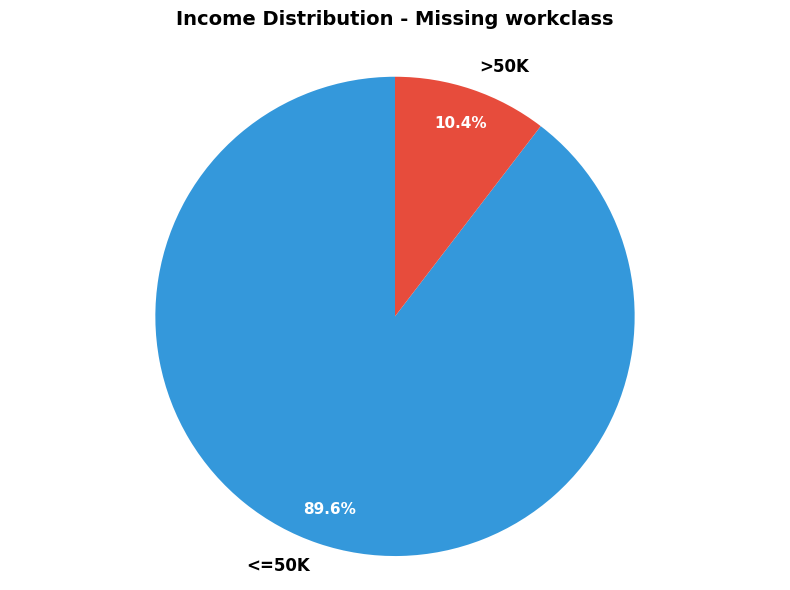

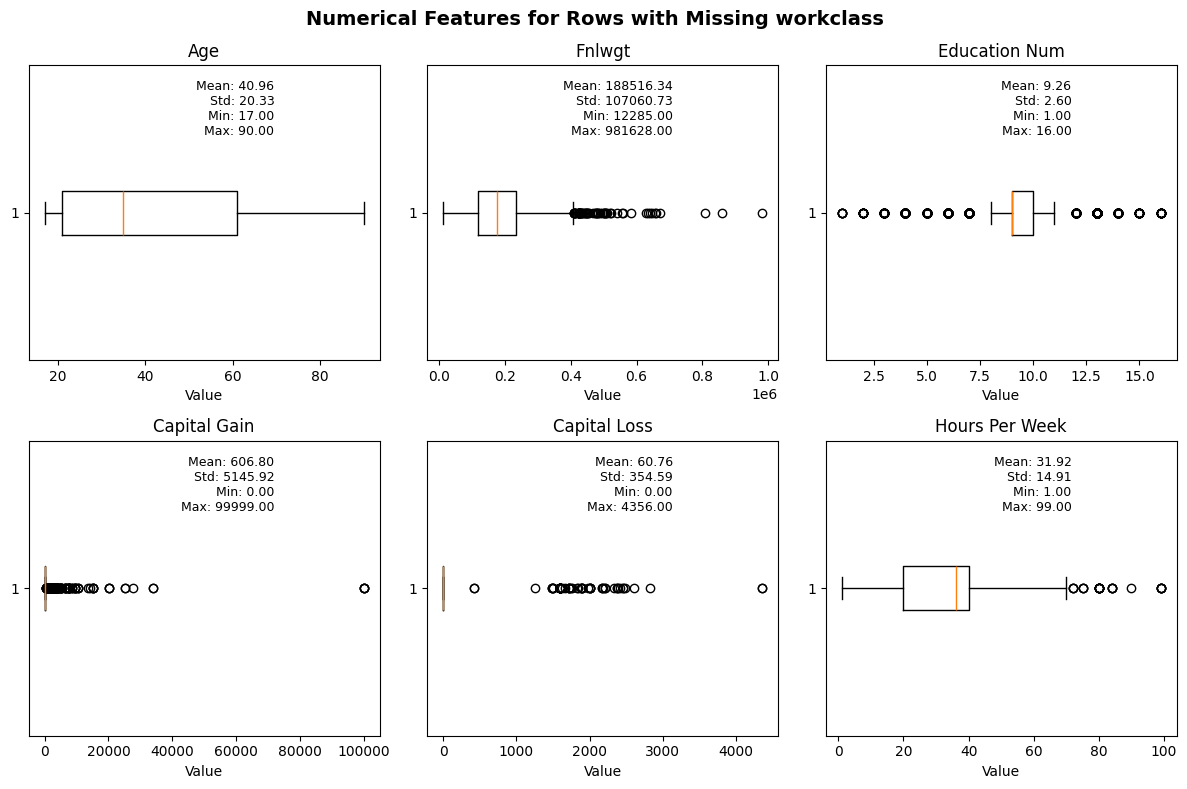

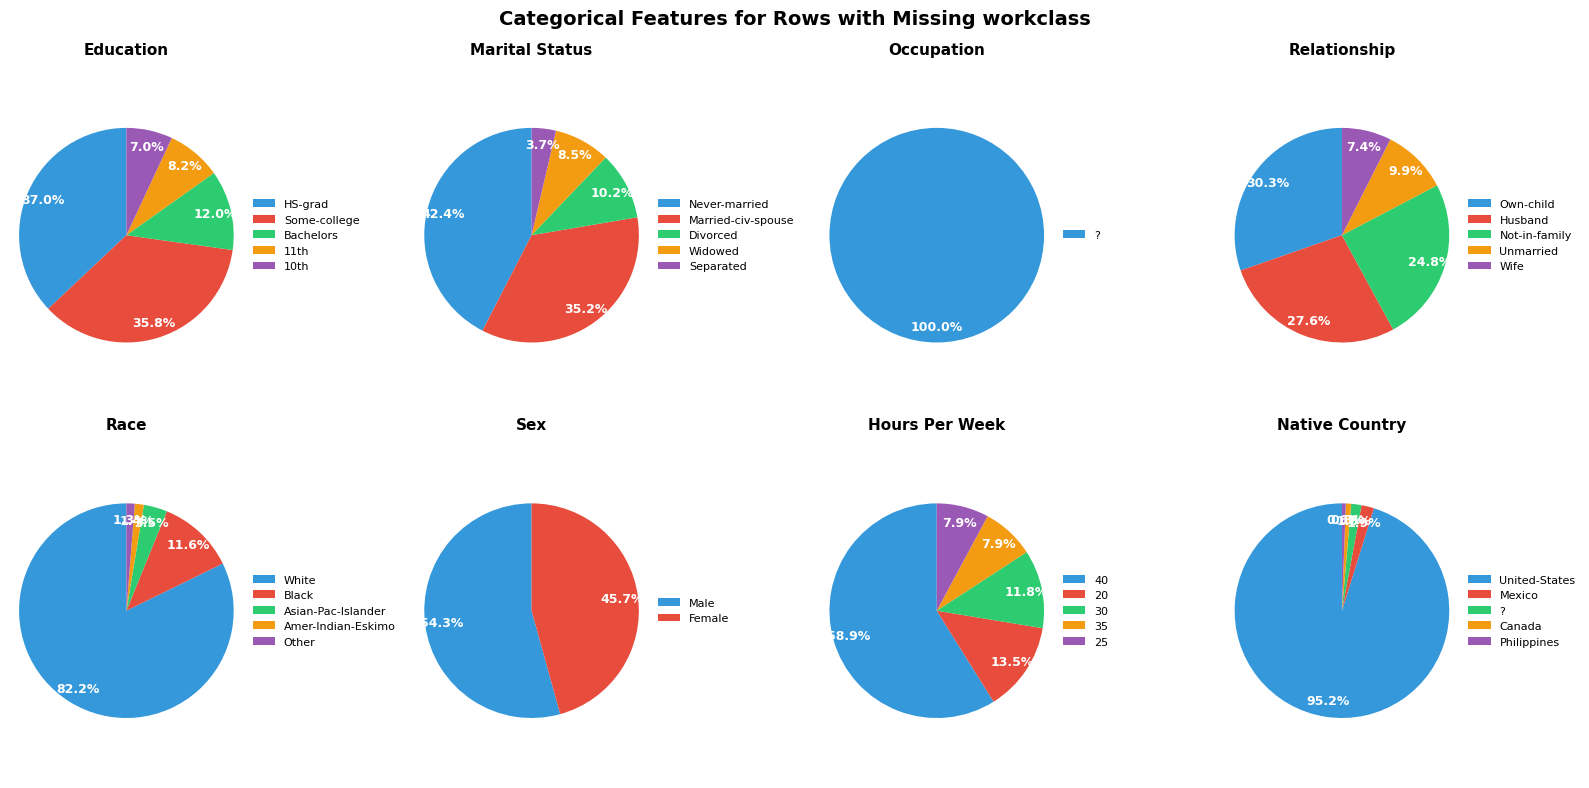




VISUALIZATIONS FOR ROWS WITH MISSING OCCUPATION



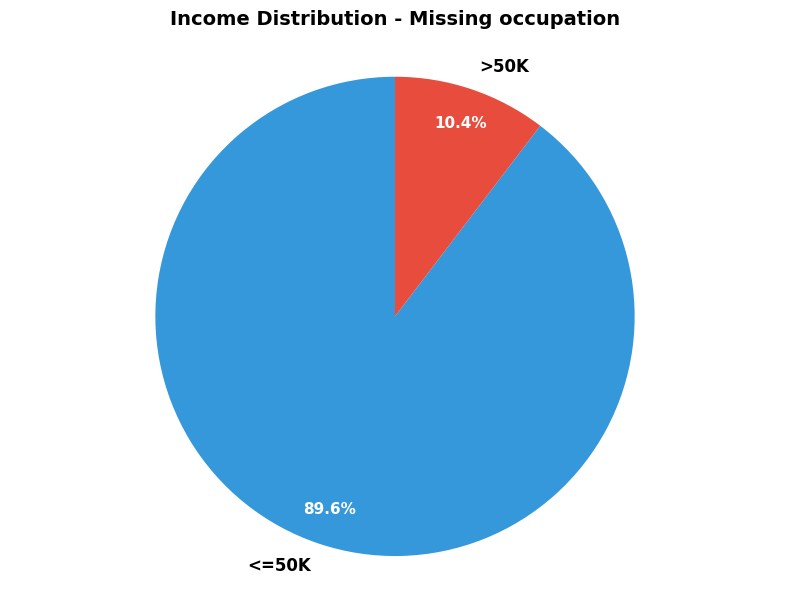

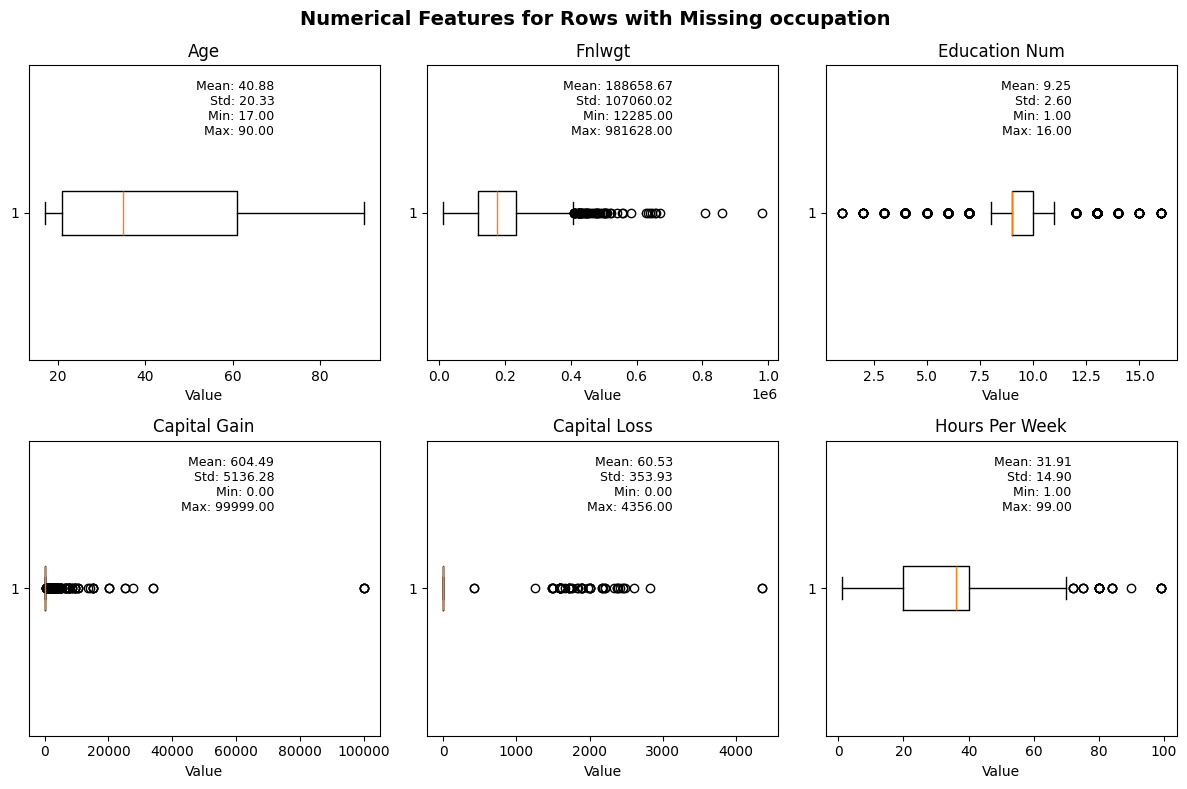

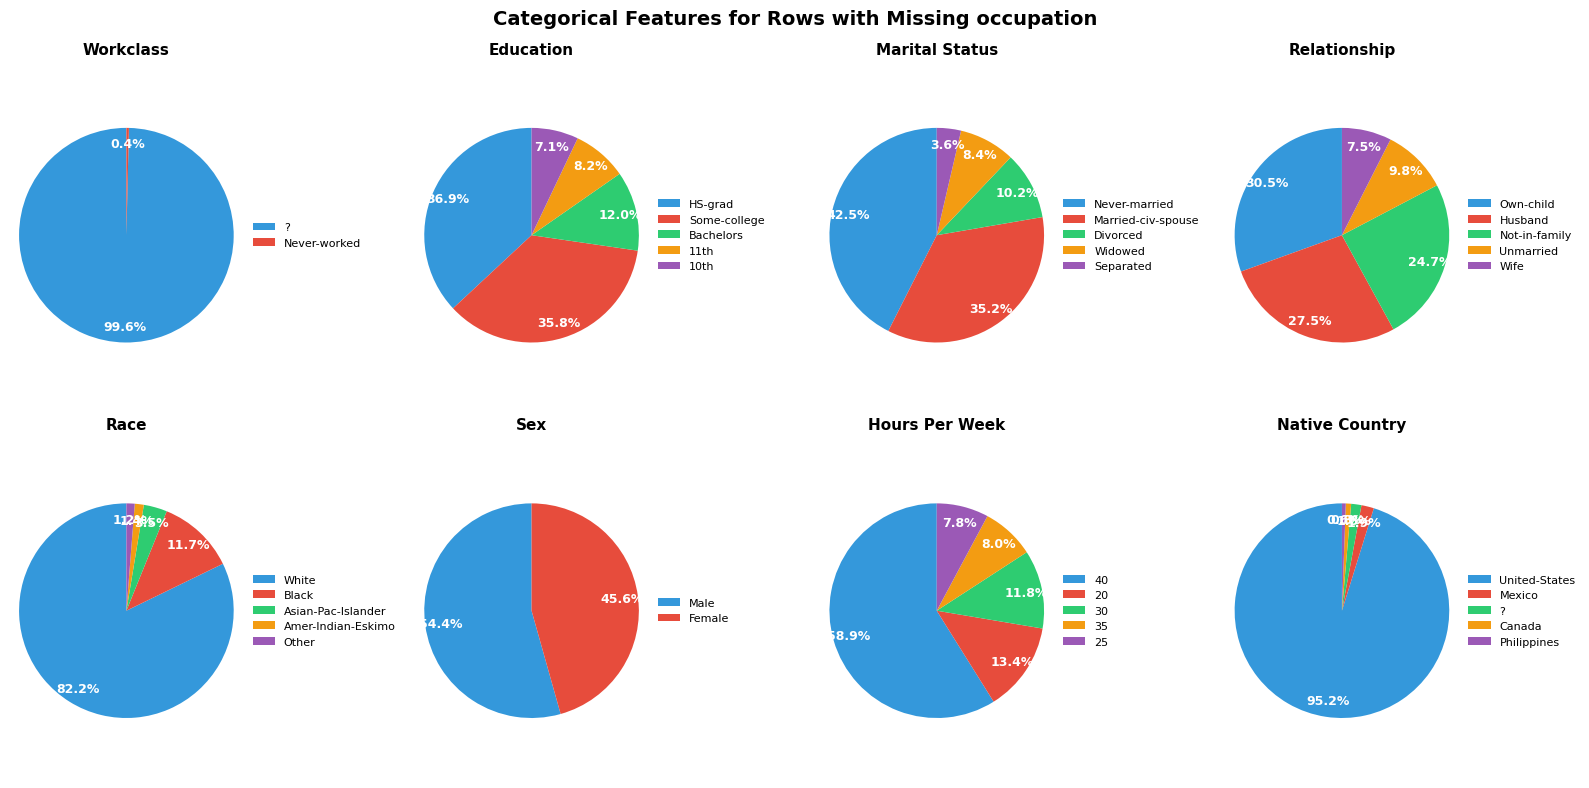




VISUALIZATIONS FOR ROWS WITH MISSING NATIVE-COUNTRY



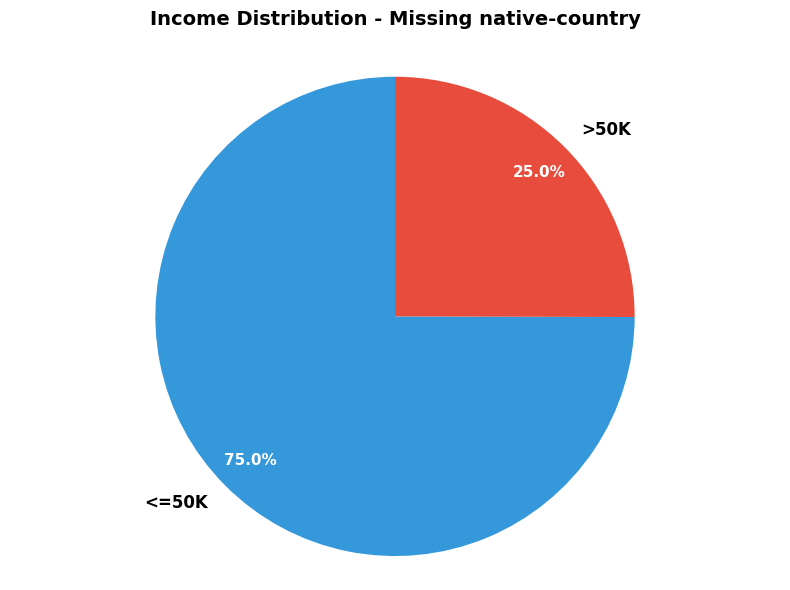

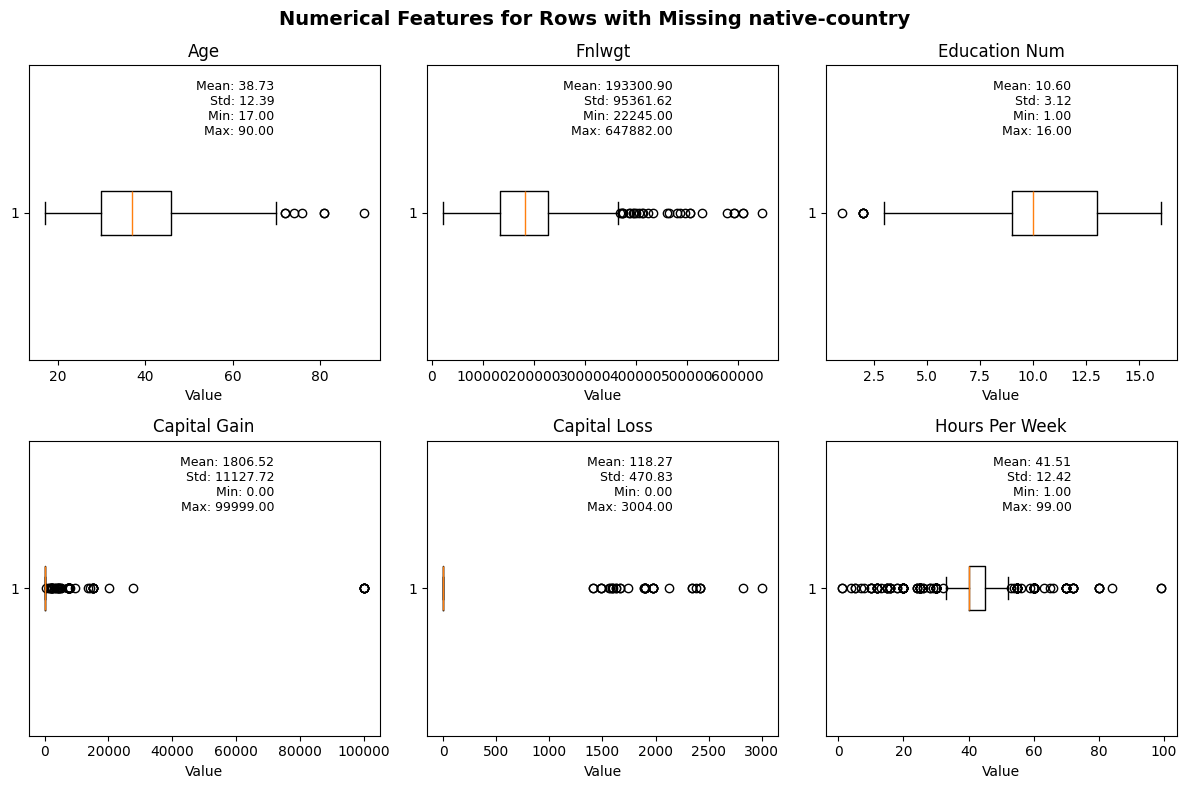

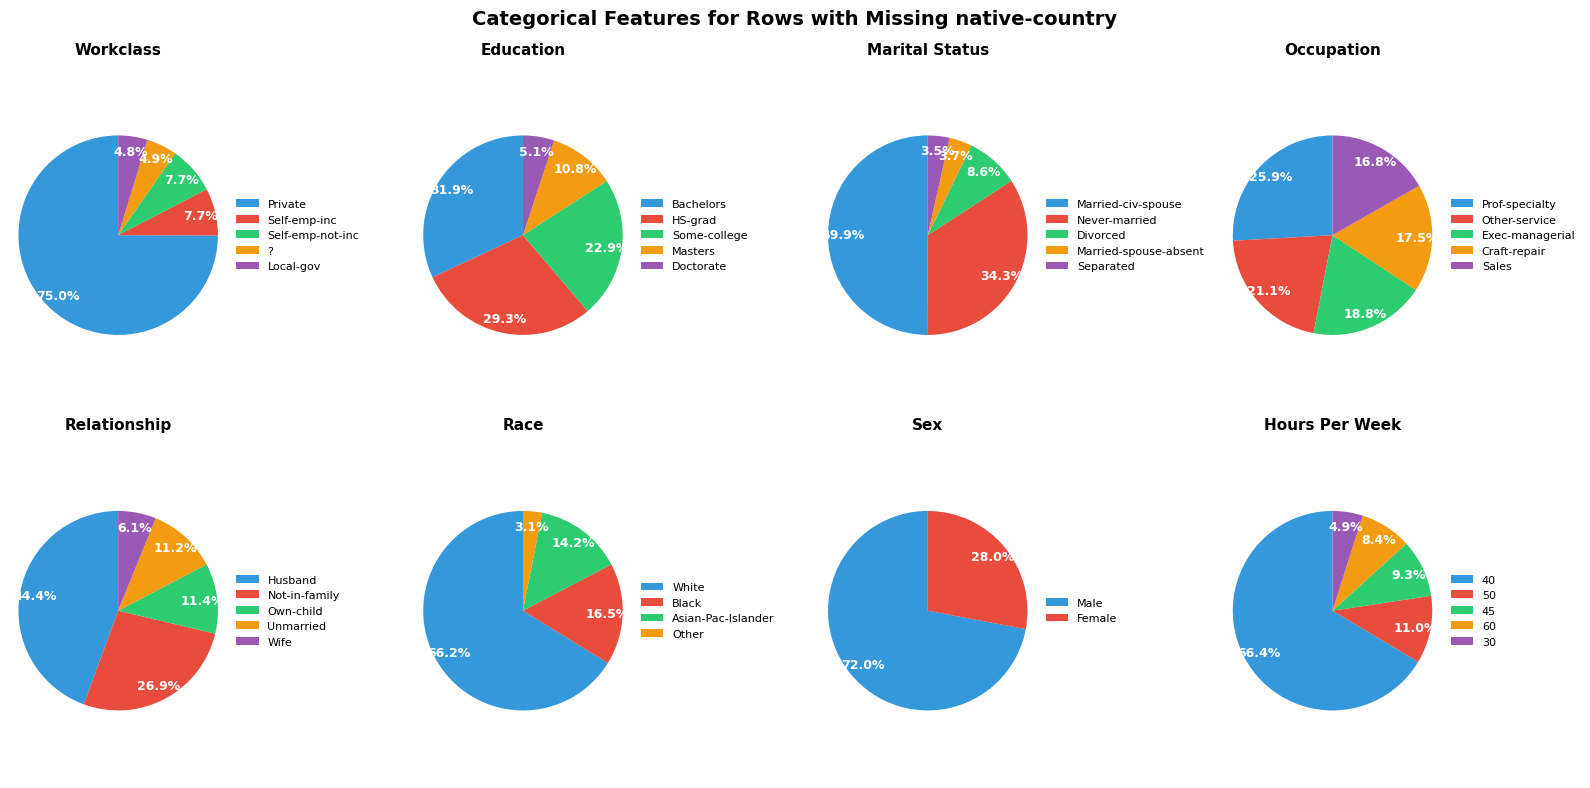

In [13]:
# Visualizations for rows with missing features

for feature_name, feat_idx in features_with_missing.items():
    print(f"\n{'='*70}")
    print(f"VISUALIZATIONS FOR ROWS WITH MISSING {feature_name.upper()}")
    print(f"{'='*70}\n")
    
    # Find rows where this specific feature is missing
    feature_missing_mask = (Xo[:, feat_idx] == "?")
    
    # Extract the rows with missing values for this feature
    X_missing = Xo[feature_missing_mask]
    y_missing = yo[feature_missing_mask]
    
    # 1. PIE CHART FOR TARGET VARIABLE (y)
    fig, ax = plt.subplots(figsize=(8, 6))
    
    unique_targets, target_counts = np.unique(y_missing, return_counts=True)
    labels = ['<=50K' if val == -1 else '>50K' for val in unique_targets]
    colors = ['#3498db', '#e74c3c']
    
    wedges, texts, autotexts = ax.pie(
        target_counts, 
        labels=labels,
        autopct='%1.1f%%',
        startangle=90,
        colors=colors,
        pctdistance=0.85
    )
    
    for autotext in autotexts:
        autotext.set_color('white')
        autotext.set_fontsize(11)
        autotext.set_weight('bold')
    
    for text in texts:
        text.set_fontsize(12)
        text.set_weight('bold')
    
    ax.set_title(
        f'Income Distribution - Missing {feature_name}', 
        fontsize=14, 
        fontweight='bold',
        pad=20
    )
    ax.axis('equal')
    plt.tight_layout()
    plt.show()
    
    # 2. BOX PLOTS FOR NUMERICAL FEATURES
    fig, axes = plt.subplots(2, 3, figsize=(12, 8))
    fig.suptitle(f'Numerical Features for Rows with Missing {feature_name}', fontsize=14, fontweight='bold')
    fig.subplots_adjust(hspace=0.5)
    axes = axes.flatten()
    
    for i, int_idx in enumerate(int_indices):
        feat_data = X_missing[:, int_idx].astype(float)
        
        axes[i].set_title(features[int_idx], fontsize=12)
        axes[i].boxplot(feat_data, vert=False)
        axes[i].set_xlabel("Value", fontsize=10)
        
        stats_text = (f"Mean: {np.mean(feat_data):.2f}\n"
                     f"Std: {np.std(feat_data):.2f}\n"
                     f"Min: {np.min(feat_data):.2f}\n"
                     f"Max: {np.max(feat_data):.2f}")
        axes[i].text(0.7, 0.95, stats_text, 
                    verticalalignment="top", 
                    horizontalalignment="right", 
                    transform=axes[i].transAxes,
                    fontsize=9)
    
    plt.tight_layout()
    plt.show()
    
    # 3. PIE CHARTS FOR CATEGORICAL FEATURES
    # Exclude the current missing feature from categorical analysis
    cat_indices_filtered = [idx for idx in cat_indices if idx != feat_idx]
    
    fig, axes = plt.subplots(2, 4, figsize=(16, 8))
    fig.suptitle(f'Categorical Features for Rows with Missing {feature_name}', fontsize=14, fontweight='bold')
    fig.subplots_adjust(hspace=0.4, wspace=0.3)
    axes = axes.flatten()
    
    colors_palette = ['#3498db', '#e74c3c', '#2ecc71', '#f39c12', '#9b59b6', '#95a5a6']
    
    for plot_idx, cat_idx in enumerate(cat_indices_filtered):
        feat_data = X_missing[:, cat_idx].astype(str)
        unique, counts = np.unique(feat_data, return_counts=True)
        
        # Sort and take top 5
        indices = np.argsort(counts)[::-1]
        unique = unique[indices]
        counts = counts[indices]
        
        top_unique = list(unique[:5])
        top_counts = list(counts[:5])
        
        wedges, texts, autotexts = axes[plot_idx].pie(
            top_counts, 
            autopct='%1.1f%%',
            startangle=90,
            colors=colors_palette[:len(top_counts)],
            pctdistance=0.85
        )
        
        for autotext in autotexts:
            autotext.set_color('white')
            autotext.set_fontsize(9)
            autotext.set_weight('bold')
        
        axes[plot_idx].set_title(
            f"{features[cat_idx]}", 
            fontsize=11, 
            fontweight='bold',
            pad=10
        )
        
        axes[plot_idx].legend(
            wedges, 
            top_unique,
            loc="center left",
            bbox_to_anchor=(1, 0, 0.5, 1),
            fontsize=8,
            frameon=False
        )
        
        axes[plot_idx].axis("equal")
    
    # Remove unused subplots
    for i in range(len(cat_indices_filtered), len(axes)):
        fig.delaxes(axes[i])
    
    plt.tight_layout()
    plt.show()
    
    print("\n")

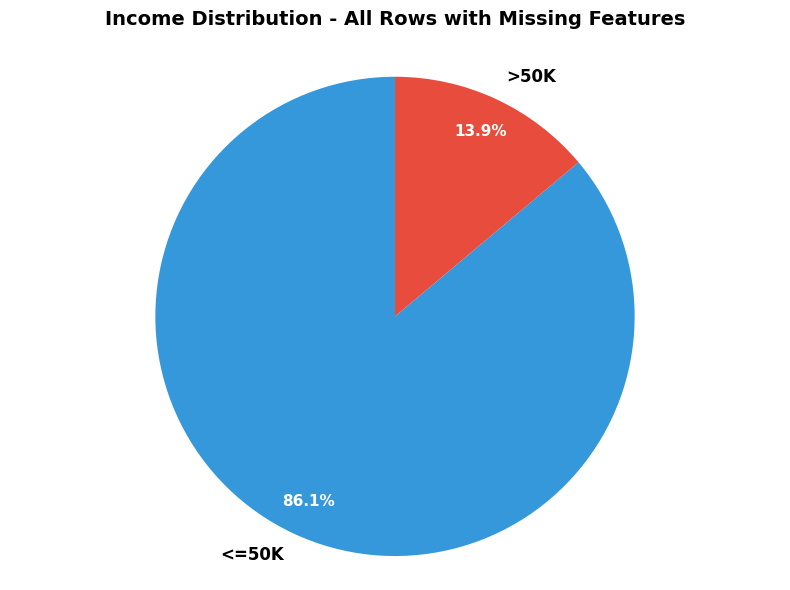

Class distribution for rows with missing features:
  <=50K: 2066 (86.12%)
  >50K: 333 (13.88%)


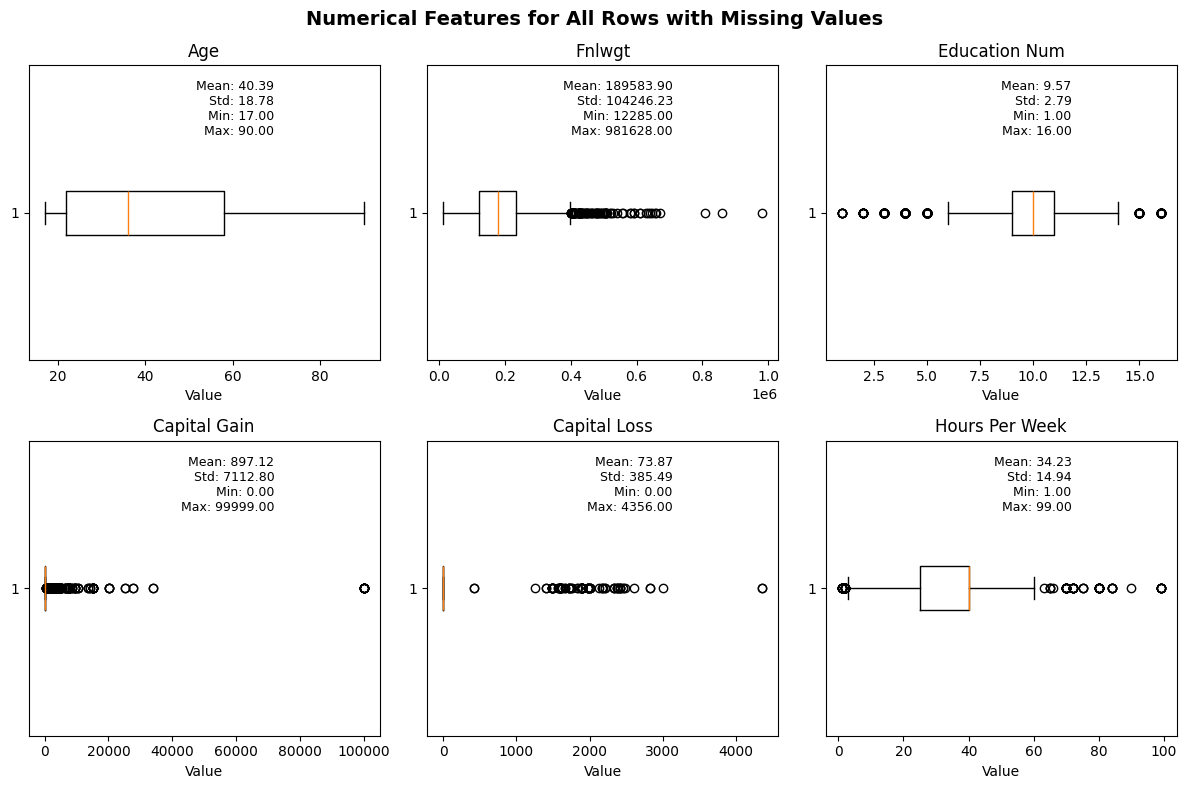

IndexError: index 8 is out of bounds for axis 0 with size 8

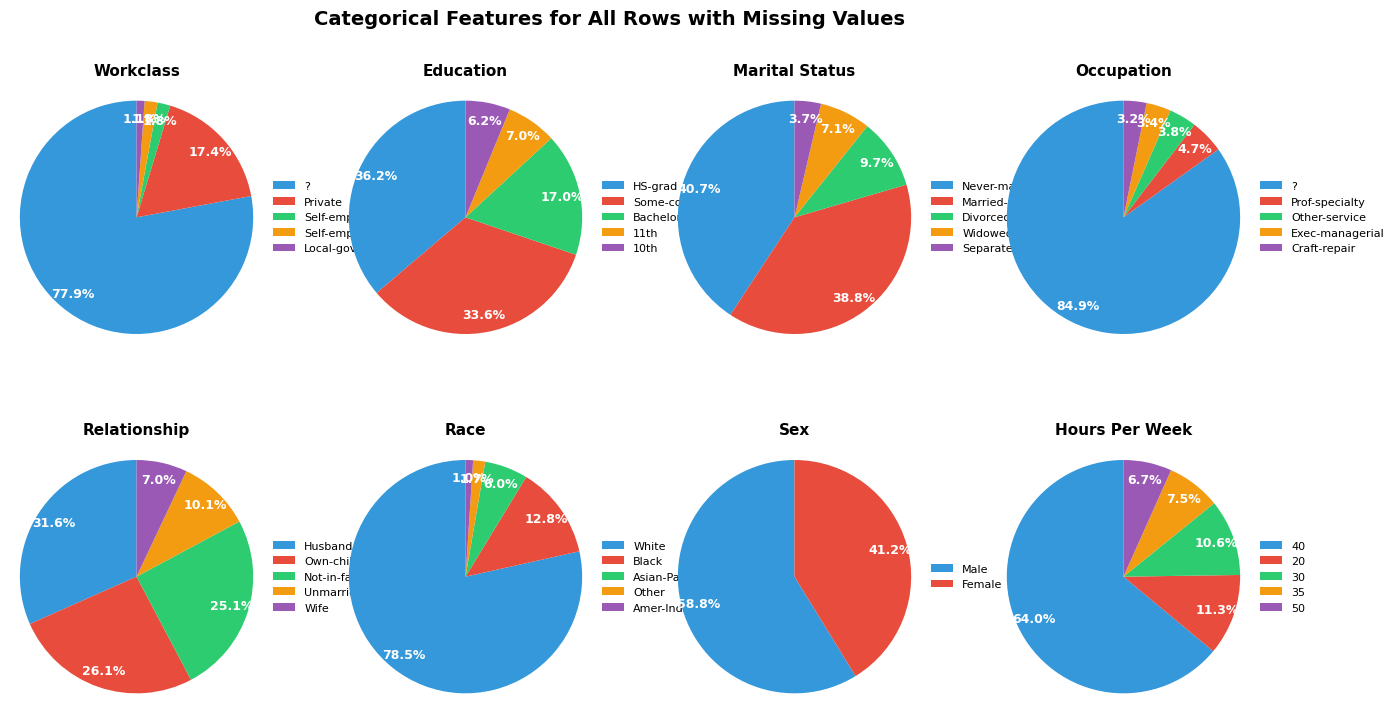

In [14]:
# Extract all rows with any missing values
X_all_missing = Xo[rows_with_missing]
y_all_missing = yo[rows_with_missing]

# 1. PIE CHART FOR TARGET VARIABLE (y)
fig, ax = plt.subplots(figsize=(8, 6))

unique_targets, target_counts = np.unique(y_all_missing, return_counts=True)
labels = ['<=50K' if val == -1 else '>50K' for val in unique_targets]
colors = ['#3498db', '#e74c3c']

wedges, texts, autotexts = ax.pie(
    target_counts, 
    labels=labels,
    autopct='%1.1f%%',
    startangle=90,
    colors=colors,
    pctdistance=0.85
)

for autotext in autotexts:
    autotext.set_color('white')
    autotext.set_fontsize(11)
    autotext.set_weight('bold')

for text in texts:
    text.set_fontsize(12)
    text.set_weight('bold')

ax.set_title(
    'Income Distribution - All Rows with Missing Features', 
    fontsize=14, 
    fontweight='bold',
    pad=20
)
ax.axis('equal')
plt.tight_layout()
plt.show()

print(f"Class distribution for rows with missing features:")
for label, count in zip(labels, target_counts):
    pct = (count / len(y_all_missing)) * 100
    print(f"  {label}: {count} ({pct:.2f}%)")

# 2. BOX PLOTS FOR NUMERICAL FEATURES
fig, axes = plt.subplots(2, 3, figsize=(12, 8))
fig.suptitle('Numerical Features for All Rows with Missing Values', fontsize=14, fontweight='bold')
fig.subplots_adjust(hspace=0.5)
axes = axes.flatten()

for i, int_idx in enumerate(int_indices):
    feat_data = X_all_missing[:, int_idx].astype(float)
    
    axes[i].set_title(features[int_idx], fontsize=12)
    axes[i].boxplot(feat_data, vert=False)
    axes[i].set_xlabel("Value", fontsize=10)
    
    stats_text = (f"Mean: {np.mean(feat_data):.2f}\n"
                 f"Std: {np.std(feat_data):.2f}\n"
                 f"Min: {np.min(feat_data):.2f}\n"
                 f"Max: {np.max(feat_data):.2f}")
    axes[i].text(0.7, 0.95, stats_text, 
                verticalalignment="top", 
                horizontalalignment="right", 
                transform=axes[i].transAxes,
                fontsize=9)

plt.tight_layout()
plt.show()

# 3. PIE CHARTS FOR CATEGORICAL FEATURES
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
fig.suptitle('Categorical Features for All Rows with Missing Values', fontsize=14, fontweight='bold')
fig.subplots_adjust(hspace=0.4, wspace=0.3)
axes = axes.flatten()

colors_palette = ['#3498db', '#e74c3c', '#2ecc71', '#f39c12', '#9b59b6', '#95a5a6']

for plot_idx, cat_idx in enumerate(cat_indices):
    feat_data = X_all_missing[:, cat_idx].astype(str)
    unique, counts = np.unique(feat_data, return_counts=True)
    
    # Sort and take top 5
    indices = np.argsort(counts)[::-1]
    unique = unique[indices]
    counts = counts[indices]
    
    top_unique = list(unique[:5])
    top_counts = list(counts[:5])
    
    wedges, texts, autotexts = axes[plot_idx].pie(
        top_counts, 
        autopct='%1.1f%%',
        startangle=90,
        colors=colors_palette[:len(top_counts)],
        pctdistance=0.85
    )
    
    for autotext in autotexts:
        autotext.set_color('white')
        autotext.set_fontsize(9)
        autotext.set_weight('bold')
    
    axes[plot_idx].set_title(
        f"{features[cat_idx]}", 
        fontsize=11, 
        fontweight='bold',
        pad=10
    )
    
    axes[plot_idx].legend(
        wedges, 
        top_unique,
        loc="center left",
        bbox_to_anchor=(1, 0, 0.5, 1),
        fontsize=8,
        frameon=False
    )
    
    axes[plot_idx].axis("equal")

# Remove unused subplots
for i in range(len(cat_indices), len(axes)):
    fig.delaxes(axes[i])

plt.tight_layout()
plt.show()

print("\n")

## Logistic Regression Model (Baseline) 

In [ ]:
# split the data into training and testing sets using a 90-10 split
X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size = 0.1, shuffle = True)

print(f"Training Data Size: {X_tr.shape[0]}")
print(f"Validation Data Size: {X_te.shape[0]}")

Training Data Size: 41798
Validation Data Size: 4645


In [ ]:
# preprocess our data
# run StandardScaler on any numerical data and OneHotEncoder on categorical data
preprocessor = ColumnTransformer(
    transformers = [
        ('num', StandardScaler(), int_indices),
        ('cat', OneHotEncoder(handle_unknown = 'ignore', sparse_output=False), cat_indices)
    ],
    remainder='drop'
)

preprocessor.fit(X_tr)
X_tr = preprocessor.transform(X_tr)
X_te = preprocessor.transform(X_te)

In [ ]:
# Logistic Regression model (baseline)
logreg_classifier = LogisticRegression(max_iter = 10000)
logreg_classifier.fit(X_tr, y_tr)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,10000
,multi_class,'deprecated'


In [ ]:
# compute error rates
ytr_pred = logreg_classifier.predict(X_tr)
yte_pred = logreg_classifier.predict(X_te)

tr_err = zero_one_loss(y_tr, ytr_pred, normalize = True)
te_err = zero_one_loss(y_te, yte_pred, normalize = True)
tr_f1 = f1_score(y_tr, ytr_pred)
te_f1 = f1_score(y_te, yte_pred)

print(f"Training Error Rate: {tr_err}")
print(f"Testing Error Rate: {te_err}")
print(f"Training F1 Score: {tr_f1}")
print(f"Testing F1 Score: {te_f1}")
print(f"Accuracy: {1 - te_err}")

Training Error Rate: 0.33838939662184797
Testing Error Rate: 0.34703982777179765
Training F1 Score: 0.6610754337199272
Testing F1 Score: 0.6471103327495622
Accuracy: 0.6529601722282024


## Random Forests

In [16]:
# split the data into training and testing sets using a 90-10 split
X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size = 0.1, shuffle = True)

print(f"Training Data Size: {X_tr.shape[0]}")
print(f"Validation Data Size: {X_te.shape[0]}")

Training Data Size: 41798
Validation Data Size: 4645


In [17]:
# preprocess our data
# run StandardScaler on any numerical data and OneHotEncoder on categorical data
preprocessor = ColumnTransformer(
    transformers = [
        ('num', StandardScaler(), int_indices),
        ('cat', OneHotEncoder(handle_unknown = 'ignore', sparse_output=False), cat_indices)
    ],
    remainder='drop'
)

preprocessor.fit(X_tr)
X_tr = preprocessor.transform(X_tr)
X_te = preprocessor.transform(X_te)

In [ ]:
decision_trees = []
for i in range(50):
    indices = np.random.choice(len(X_tr), size = len(X_tr), replace = True)
    X_bootstrap = X_tr[indices]
    Y_bootstrap = y_tr[indices]

    decision_tree = tree.DecisionTreeClassifier(max_depth = 20, min_samples_leaf = 2, criterion = 'entropy')

    decision_tree.fit(X_bootstrap, Y_bootstrap)
    decision_trees.append(decision_tree)


ensemble = [1, 5, 11, 25, 51]
tr_errors = []
val_errors = []
f1_scores = []

for size in ensemble:
    # training
    predictions = [t.predict(X_tr) for t in decision_trees[:size]]
    tr_pred = np.sign(np.mean(np.array(predictions), axis = 0))

    tr_error = zero_one_loss(y_tr, tr_pred)
    tr_errors.append(tr_error)

    # testing
    predictions = [t.predict(X_te) for t in decision_trees[:size]]
    val_pred = np.where(np.mean(np.array(predictions), axis = 0) >= 0, 1.0, -1.0)


    val_error = zero_one_loss(y_te, val_pred)
    val_errors.append(val_error)

    te_f1 = f1_score(y_te, val_pred)
    f1_scores.append(te_f1)

plt.title('Ensemble Size vs. Error Rate')
plt.xlabel('Ensemble Size')            
plt.ylabel('Error Rate')

plt.plot(ensemble, tr_errors, marker = 'o', label = 'Training Error')
plt.plot(ensemble, val_errors, marker = 'o', label = 'Validation Error')

plt.legend()
plt.show()

print(f"Best Testing Error: {min(tr_errors)}")
print(f"Best F1 Score: {max(f1_scores)}")

ValueError: Target is multiclass but average='binary'. Please choose another average setting, one of [None, 'micro', 'macro', 'weighted'].